In [10]:
pip install faker


In [11]:
import pandas as pd
import random
from faker import Faker
import matplotlib.pyplot as plt

In [12]:
fake=Faker()

Sample Data:

  Patient_ID             Name  Age  Gender        Disease  Sugar_Level  \
0       P001      Alex Archer   61  Female   Hypertension           88   
1       P002  Rachel Martinez   63    Male          Fever          115   
2       P003   Adriana Dorsey   26    Male  Heart Disease          192   
3       P004    Shannon Perez   80    Male   Hypertension          121   
4       P005   Melinda Miller   76  Female   Hypertension          217   

   Heart_Rate            City Admission_Date  
0          64     Adkinsburgh     2026-02-10  
1          80    Campbellside     2026-01-23  
2         107     Port Nicole     2026-01-12  
3          67  Cassandrahaven     2026-03-02  
4          73      North Jack     2026-03-25  

CSV file saved successfully!

Total Patients: 100

Average Age: 51.66

Disease Count:
 Disease
Hypertension     27
Fever            25
Diabetes         18
Asthma           17
Heart Disease    13
Name: count, dtype: int64

High Sugar Patients:
    Patient_ID 

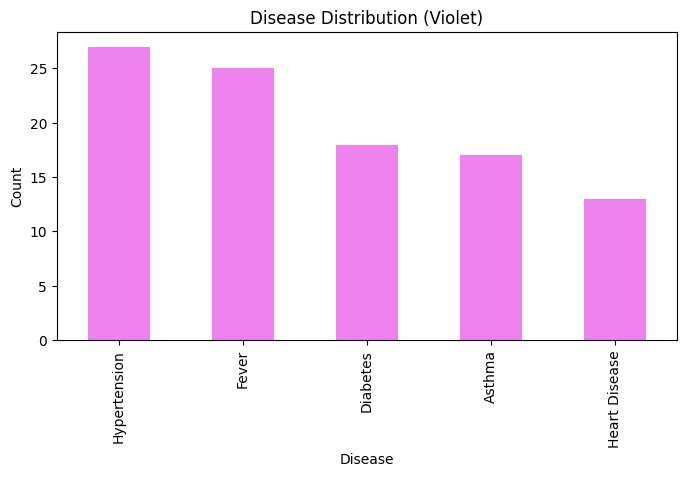

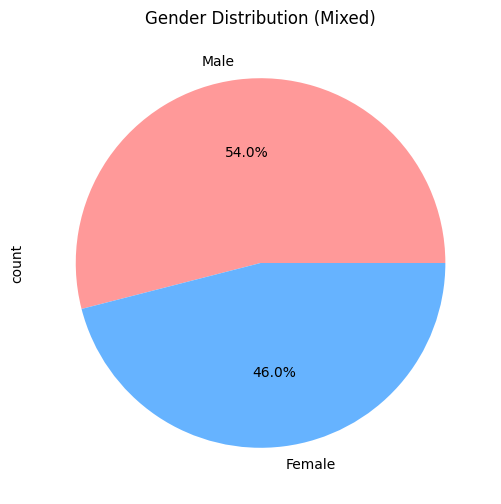

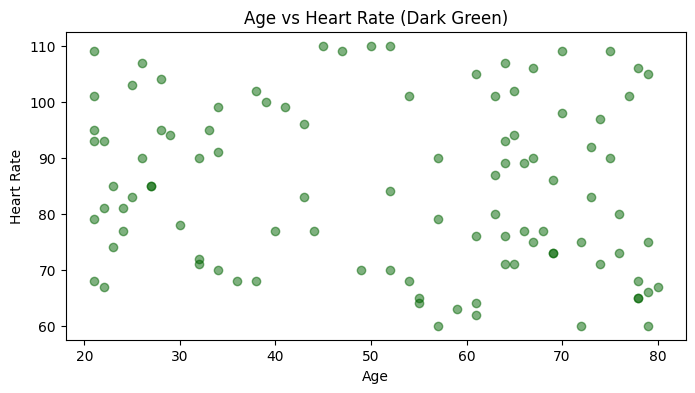

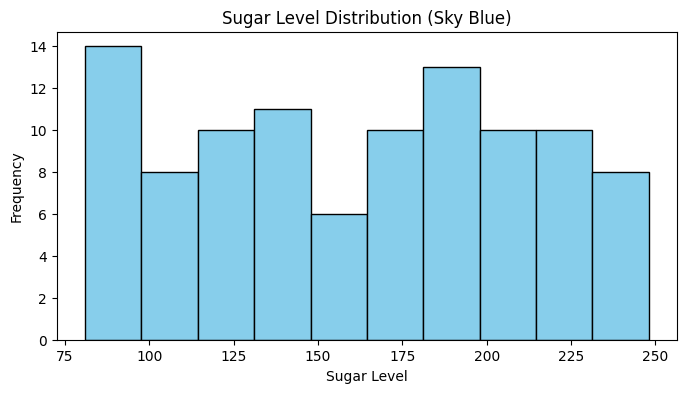

In [14]:
num_records = 100

diseases = ["Diabetes", "Hypertension", "Heart Disease", "Fever", "Asthma"]
genders = ["Male", "Female"]

data = []

for i in range(num_records):
    patient = {
        "Patient_ID": f"P{i+1:03}",
        "Name": fake.name(),
        "Age": random.randint(20, 80),
        "Gender": random.choice(genders),
        "Disease": random.choice(diseases),
        "Sugar_Level": random.randint(80, 250),
        "Heart_Rate": random.randint(60, 110),
        "City": fake.city(),
        "Admission_Date": fake.date_this_year()
    }
    data.append(patient)

df = pd.DataFrame(data)


print("Sample Data:\n")
print(df.head())

df.to_csv("patient_data.csv", index=False)
print("\nCSV file saved successfully!")

print("\nTotal Patients:", len(df))
print("\nAverage Age:", df["Age"].mean())

print("\nDisease Count:\n", df["Disease"].value_counts())

high_sugar = df[df["Sugar_Level"] > 180]
print("\nHigh Sugar Patients:\n", high_sugar.head())

high_heart_rate = df[df["Heart_Rate"] > 100]

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['Disease'].value_counts().plot(kind='bar', color='violet')
plt.title('Disease Distribution (Violet)')
plt.xlabel('Disease')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(6, 6))
colors = ['#ff9999','#66b3ff']
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=colors)
plt.title('Gender Distribution (Mixed)')
plt.show()

plt.figure(figsize=(8, 4))
plt.scatter(df['Age'], df['Heart_Rate'], color='darkgreen', alpha=0.5)
plt.title('Age vs Heart Rate (Dark Green)')
plt.xlabel('Age')
plt.ylabel('Heart Rate')
plt.show()

plt.figure(figsize=(8, 4))
n, bins, patches = plt.hist(df['Sugar_Level'], bins=10, color='skyblue', edgecolor='black')
plt.title('Sugar Level Distribution (Sky Blue)')
plt.xlabel('Sugar Level')
plt.ylabel('Frequency')
plt.show()

